# TME Music Data Analysis Pipeline
This notebook imports modularized functions from `pipeline`, `reporting`, and `plotting` to perform ETL, analysis, and report generation.

In [1]:
import pandas as pd
from config import (
    BASE_PATH, 
    START_MONTH, 
    END_MONTH, 
    TOP_N_SONGS, 
    TOP_N_ALBUMS, 
    OUTPUT_SONG_REPORT_PATH, 
    OUTPUT_ALBUM_REPORT_PATH
)
from pipeline import run_etl_pipeline, clean_and_unify_data
from reporting import generate_song_report, generate_album_report
import plotting

## 1. Run ETL Pipeline
Extract data from all raw TME Excel files, calculate platform-specific click metrics, and clean the dataset.

In [2]:
# Run the ETL pipeline to ingest files
df_raw = run_etl_pipeline(BASE_PATH)

# Clean dates, unify platforms, and standardize metadata names
df_cleaned = clean_and_unify_data(df_raw)
df_cleaned.head()

/Users/chu-chun/Mirror/Eva/pipeline.py:95: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_raw = pd.concat(all_data, ignore_index=True)


,YearMonth,Platform,Song,ISRC,Artist,Album,UPC,Revenue,Total_Clicks,source_file,standard_song,standard_artist
155293,2024-01,UltimateMusic,楼台会,HKG631877019,"关菊英,罗文",娱乐千禧精选,UPC-4715202901043,0.016488,1.0,aiting_song_outside_detail_CON02-TME00-2023073...,楼台会,仙杜拉
156654,2024-01,Kugou,郎归晚(Live),HKG631895046,汪明荃,汪明荃演唱会,UPC-4715202900978,8.629039,516.0,song_outside_detail_CON02-TME00-20230731-0006_...,郎归晚(Live),汪明荃
156653,2024-01,Kugou,千王群英会(Live),HKG631895045,汪明荃,汪明荃演唱会,UPC-4715202900978,0.138293,114.0,song_outside_detail_CON02-TME00-20230731-0006_...,千王群英会(Live,汪明荃
156652,2024-01,Kugou,用爱将心偷(Live),HKG631895044,汪明荃,汪明荃演唱会,UPC-4715202900978,28.407109,1565.0,song_outside_detail_CON02-TME00-20230731-0006_...,用爱将心偷(Live,汪明荃
156651,2024-01,Kugou,笑看风云(Live),HKG631895043,郑少秋,汪明荃演唱会,UPC-4715202900978,124.408332,40075.0,song_outside_detail_CON02-TME00-20230731-0006_...,笑看风云(Live),汪明荃


## 2. Monthly Revenue Trend
Plot total monthly revenue and show MoM Growth Percentage.

Monthly Revenue and Clicks Summary:


,YearMonth,revenue,clicks,MoM_Growth_Pct
0,2024-01,209852.614793,41898331.0,N/A
1,2024-02,181187.358897,30164543.0,-13.66%
2,2024-03,172952.888586,34689443.0,-4.54%
3,2024-04,156989.774356,33077023.0,-9.23%
4,2024-05,158067.851149,33141912.0,0.69%
5,2024-06,152163.530656,30624103.0,-3.74%
6,2024-07,140727.737638,31094928.0,-7.52%
7,2024-08,141927.526206,31078997.0,0.85%
8,2024-09,141597.762204,30021614.0,-0.23%
9,2024-10,141382.911124,31267181.0,-0.15%


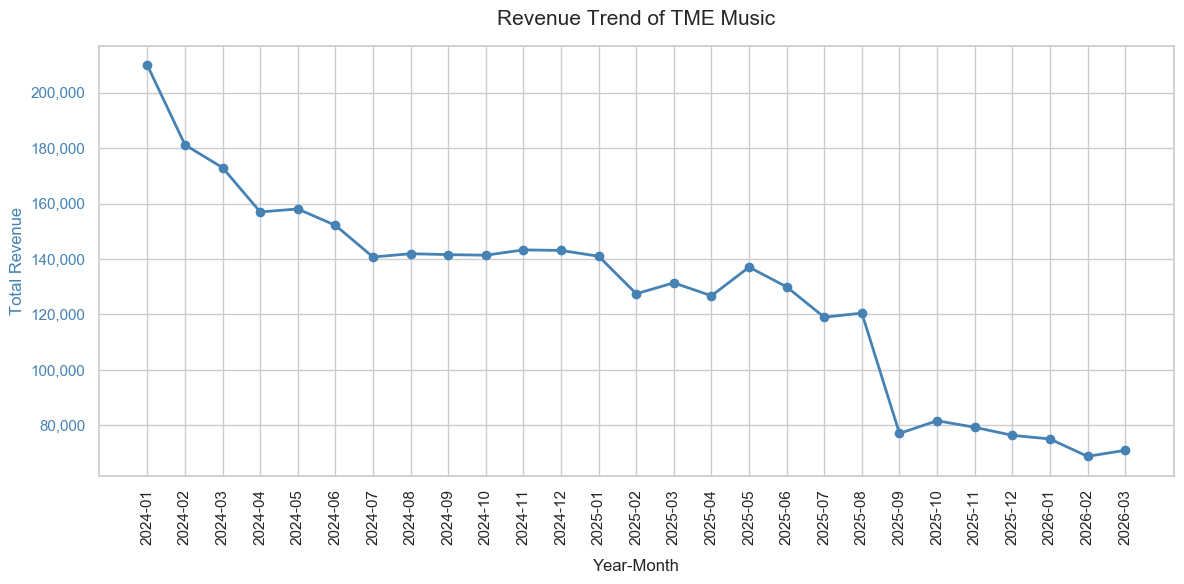

In [3]:
revenue_by_month = (
    df_cleaned.groupby('YearMonth')
    .agg(revenue=('Revenue', 'sum'), clicks=('Total_Clicks', 'sum'))
    .reset_index()
)
revenue_by_month['MoM_Growth_Pct'] = (
    revenue_by_month['revenue']
    .pct_change()
    .apply(lambda x: f"{x:.2%}" if pd.notnull(x) else "N/A")
)

print("Monthly Revenue and Clicks Summary:")
display(revenue_by_month)

# Plot revenue trend line graph
plotting.plot_revenue_trend(revenue_by_month)

## 3. Filter for Specific Analysis Period
Filter the dataset for the designated target period (e.g. 2024-01 to 2026-03).

In [5]:
df_filtered = df_cleaned[
    (df_cleaned['YearMonth'] >= START_MONTH) & 
    (df_cleaned['YearMonth'] <= END_MONTH)
]
print(f"Filtered dataset from {START_MONTH} to {END_MONTH} contains {len(df_filtered)} rows.")

Filtered dataset from 2024-01 to 2026-03 contains 275484 rows.


## 4. Song Level Analysis & Scatter Plot

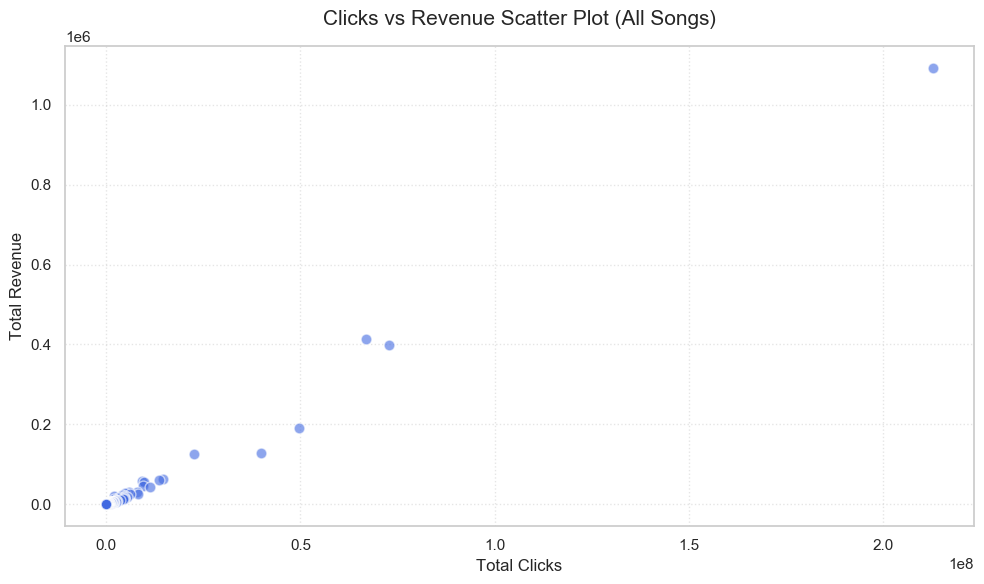

In [6]:
revenue_by_song = (
    df_filtered
    .groupby(['UPC', 'ISRC'])
    .agg(
        song=('standard_song', 'first'),
        artist=('standard_artist', 'first'),
        revenue=('Revenue', 'sum'),
        clicks=('Total_Clicks', 'sum')
    )
    .reset_index()
)
revenue_by_song = revenue_by_song.sort_values('revenue', ascending=False)

# Plot clicks vs revenue scatter plot for all songs
plotting.plot_clicks_vs_revenue(revenue_by_song, "Clicks vs Revenue Scatter Plot (All Songs)")

## 5. Top Songs Share & Pie Charts

Top 10 songs contribute to 75.17% of total revenue.


,UPC,ISRC,song,artist,revenue,clicks,rev_share,click_share
550,UPC-4715202900930,HKG631895001,笑看风云,郑少秋,1.092279e+06,212721314.0,0.316975,0.295507
391,UPC-4715202900800,HKG631892001,随缘,温兆伦,4.148973e+05,66782482.0,0.120401,0.092773
495,UPC-4715202900909,HKG631892001,随缘,温兆伦,3.978303e+05,72751292.0,0.115449,0.101064
199,UPC-4715202900633,HKG631882039,万水千山总是情,汪明荃,1.909983e+05,49625102.0,0.055427,0.068938
240,UPC-4715202900671,HKG631882039,万水千山总是情,汪明荃,1.295392e+05,39918700.0,0.037592,0.055454
472,UPC-4715202900879,HKG631893007,摘下满天星,郑少秋,1.256505e+05,22546142.0,0.036463,0.031321
504,UPC-4715202900916,HKG631894001,缘份,陈松伶,6.377204e+04,14721374.0,0.018506,0.020451
907,UPC-4715202901241,HKG631895019,天地情缘,温兆伦,5.985043e+04,13576302.0,0.017368,0.018860
617,UPC-4715202900985,HKG631896029,从不放弃,郑少秋,5.964277e+04,9149163.0,0.017308,0.012710
831,UPC-4715202901173,HKG631878001,小李飞刀,罗文,5.598932e+04,9822758.0,0.016248,0.013646


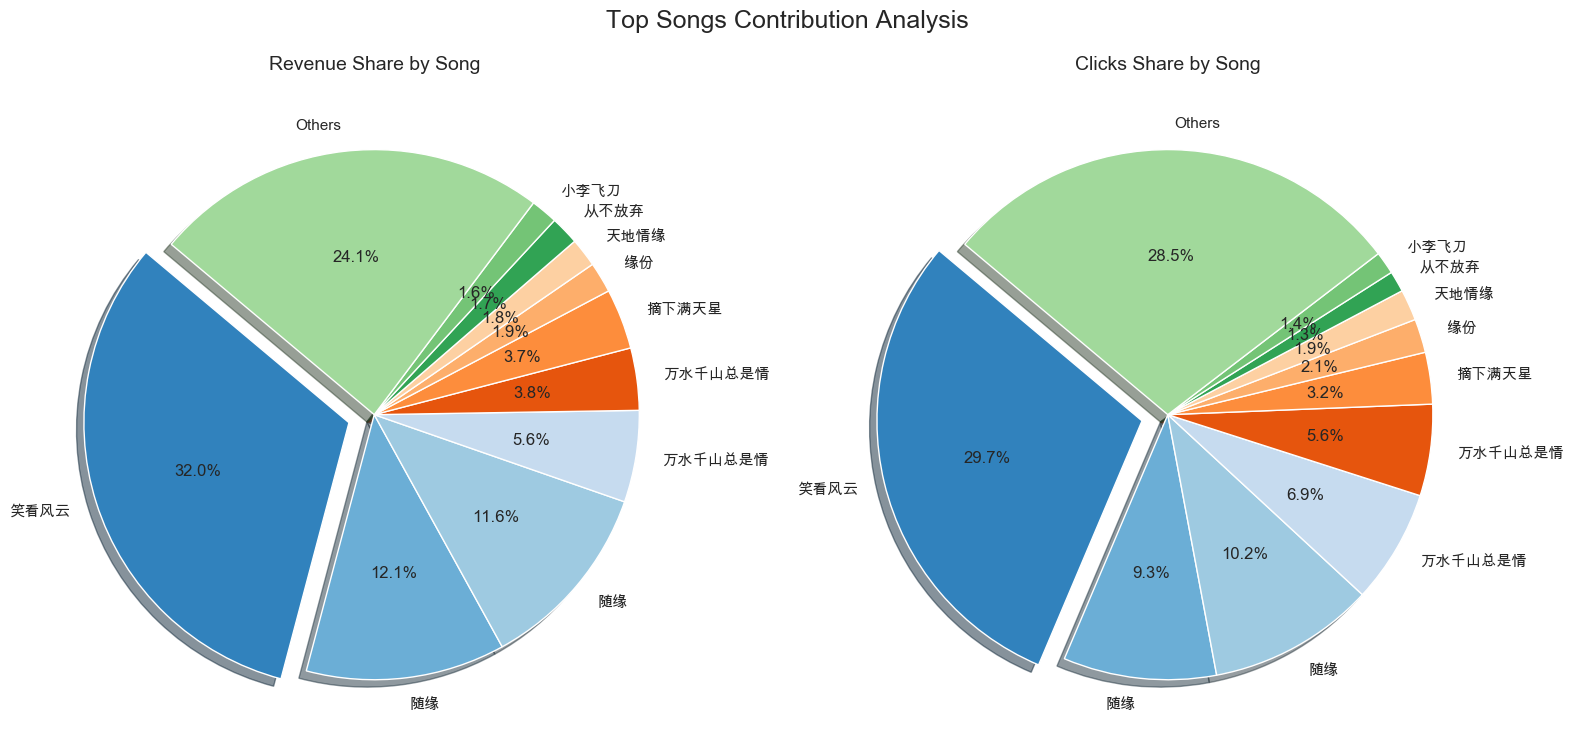

In [7]:
total_rev = revenue_by_song['revenue'].sum()
total_clicks = revenue_by_song['clicks'].sum()

revenue_by_song_top = revenue_by_song.head(TOP_N_SONGS).copy()
revenue_by_song_top['rev_share'] = revenue_by_song_top['revenue'] / total_rev
revenue_by_song_top['click_share'] = revenue_by_song_top['clicks'] / total_clicks
top_song_list = revenue_by_song_top['ISRC'].tolist()

print(f"Top {TOP_N_SONGS} songs contribute to {revenue_by_song_top['rev_share'].sum():.2%} of total revenue.")
display(revenue_by_song_top)

# Side-by-side pie charts for revenue & clicks contribution
top_song_detail = revenue_by_song.head(TOP_N_SONGS).copy()[['song', 'revenue', 'clicks']]
other_songs_rev = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['revenue'].sum()
other_songs_clicks = revenue_by_song[~revenue_by_song['ISRC'].isin(top_song_list)]['clicks'].sum()

others_row = pd.DataFrame([{
    'song': 'Others',
    'revenue': other_songs_rev,
    'clicks': other_songs_clicks
}])

df_pie = pd.concat([top_song_detail, others_row], ignore_index=True)
plotting.plot_pie_charts(df_pie)

## 6. Generate Song Report
Aggregates, pivots, and exports monthly metrics to Excel.

In [8]:
song_final = generate_song_report(df_filtered, OUTPUT_SONG_REPORT_PATH)
song_final.head()

Song report exported successfully to: TME_Song_Report_202401_202603.xlsx


,ISRC,song,artist,UPC,album,total_click,total_revenue,2024-01_clicks,2024-01_revenue,2024-02_clicks,...,2025-11_clicks,2025-11_revenue,2025-12_clicks,2025-12_revenue,2026-01_clicks,2026-01_revenue,2026-02_clicks,2026-02_revenue,2026-03_clicks,2026-03_revenue
0,HKG631895001,笑看风云,郑少秋,UPC-4715202900930,笑看风云,212721314.0,1.092279e+06,12551280.0,66241.968418,9789967.0,...,0.0,0.000000,0.0,0.000000,2390068.0,5328.494253,1781473.0,3760.102854,1903305.0,3251.710876
1,HKG631892001,随缘,温兆伦,UPC-4715202900800,我是情痴·随缘,66782482.0,4.148973e+05,7333158.0,47152.967315,4029332.0,...,1804532.0,11868.162836,1873578.0,11325.700960,1811273.0,9320.687824,1572396.0,9382.119456,1693831.0,8760.517125
2,HKG631892001,随缘,温兆伦,UPC-4715202900909,投入生命,72751292.0,3.978303e+05,6050976.0,31024.625351,3382755.0,...,2379081.0,12409.233589,2412381.0,11487.407443,2404375.0,10381.962677,1873381.0,9836.923195,2323522.0,10108.575414
3,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900633,万水千山总是情 电视剧原声带,49625102.0,1.909983e+05,2161371.0,7674.824207,2048345.0,...,1624437.0,6857.187888,1304120.0,6023.323827,1044828.0,5159.672531,870320.0,4985.058082,955162.0,4842.801410
4,HKG631882039,万水千山总是情,汪明荃,UPC-4715202900671,金曲精选,39918700.0,1.295392e+05,1661393.0,5215.694363,1431046.0,...,985232.0,3875.543862,1012740.0,3667.515475,1026187.0,3756.540136,823857.0,3365.033480,945043.0,3454.489675


## 7. Monthly Revenue Trend for Top Songs

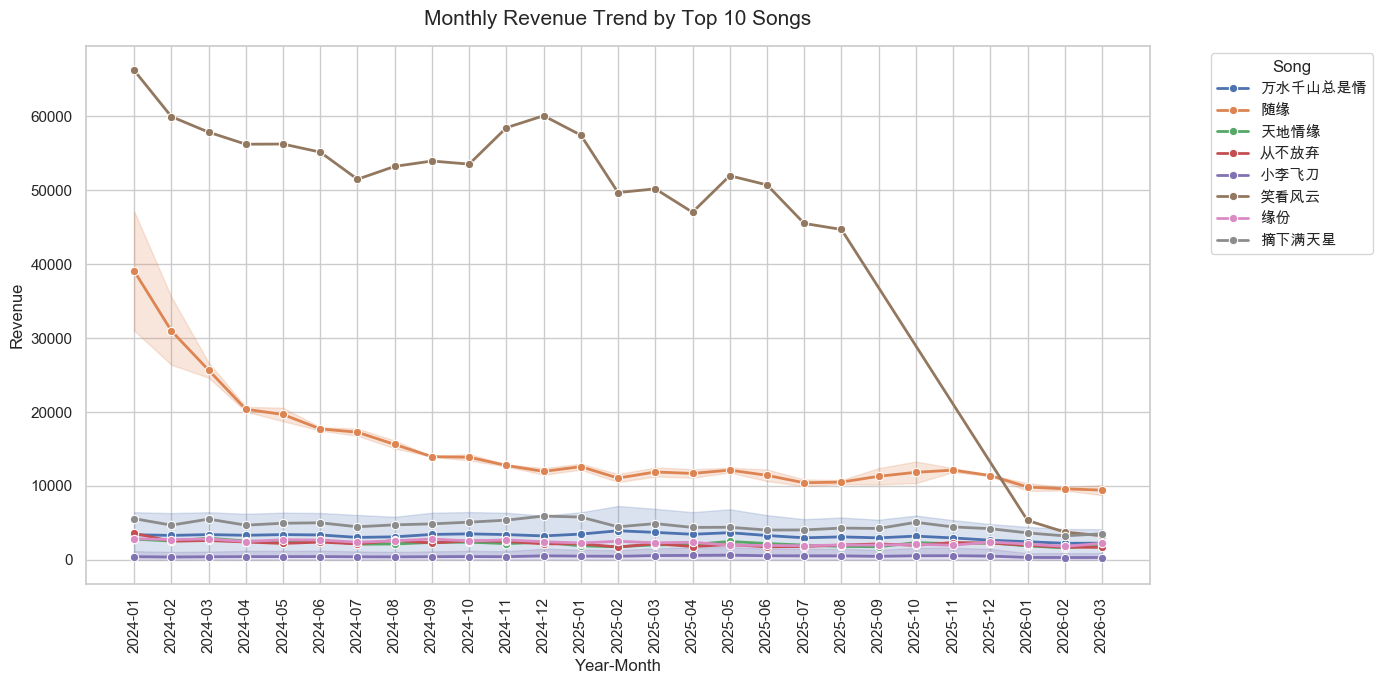

In [9]:
revenue_by_song_per_month = (
    df_filtered
    .groupby(['UPC', 'ISRC', 'YearMonth'])
    .agg(
        song=('standard_song', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
monthly_revenue_top_song = revenue_by_song_per_month[
    revenue_by_song_per_month['ISRC'].isin(top_song_list)
].sort_values('YearMonth')

plotting.plot_monthly_revenue_by_top_songs(monthly_revenue_top_song, TOP_N_SONGS)

## 8. Revenue by Platform

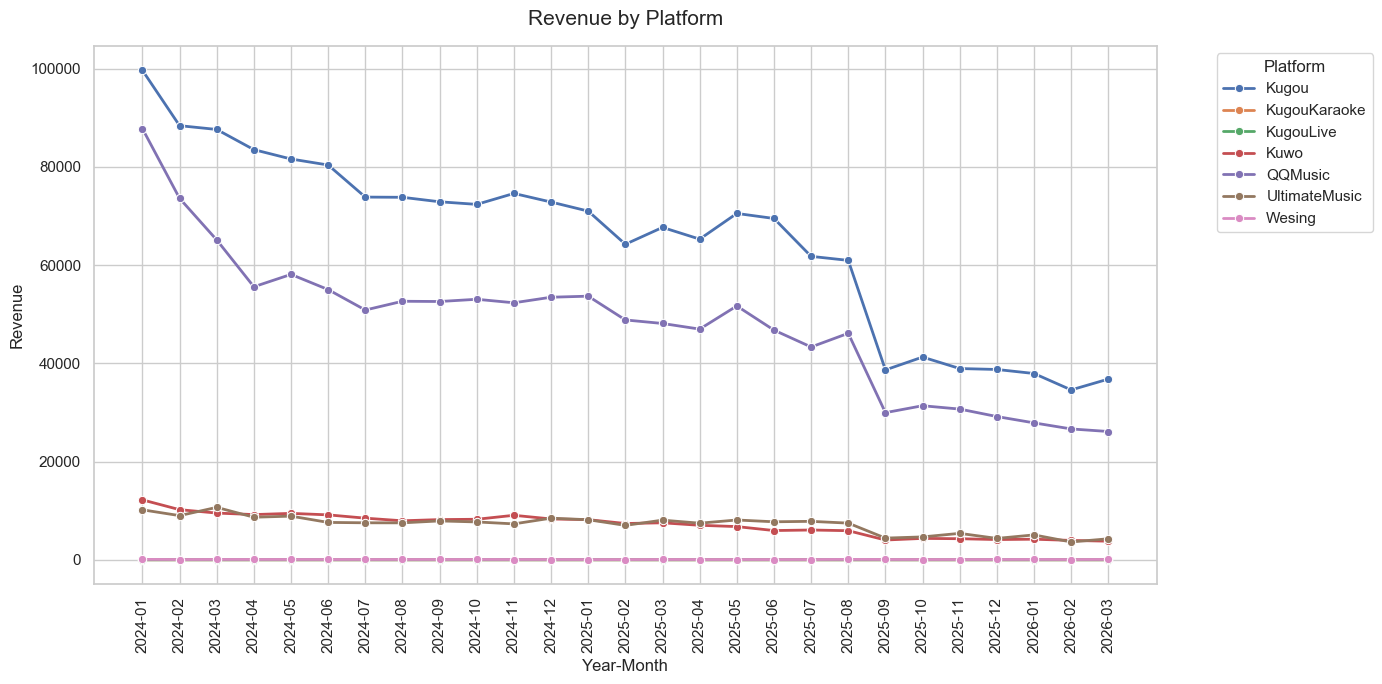

In [10]:
revenue_by_platform_per_month = (
    df_filtered
    .groupby(['ISRC', 'YearMonth', 'Platform'])
    .agg(revenue=('Revenue', 'sum'))
    .reset_index()
)
revenue_by_platform = (
    revenue_by_platform_per_month
    .groupby(['YearMonth', 'Platform'])
    .agg(revenue=('revenue', 'sum'))
    .reset_index()
)

plotting.plot_revenue_by_platform(revenue_by_platform)

## 9. Generate Album Report & Plot Revenue by Album

Album report exported successfully to: TME_Album_Revenue_Report_202306_202603.xlsx


YearMonth,UPC,album,artist,total_revenue,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,...,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03
0,UPC-4715202900930,笑看风云,郑少秋,1.100010e+06,66678.692380,60420.299180,58314.050423,56622.987910,56738.577889,55552.046532,...,51120.481571,45848.181086,45064.649043,91.465899,0.000000,0.000000,0.000000,5397.201096,3804.694493,3306.335407
1,UPC-4715202900800,我是情痴·随缘,温兆伦,4.539478e+05,48818.337451,36780.409601,28029.051457,21337.412388,22088.305765,19505.352710,...,12025.950227,11384.339517,11556.529519,11757.147749,12086.193115,13456.092189,13075.723232,10890.743748,10952.729422,10338.168431
2,UPC-4715202900909,投入生命,温兆伦,4.500289e+05,33100.717212,28192.885758,26769.465422,22689.871412,20865.024517,19566.836000,...,14382.969444,12722.429863,12610.764471,14148.889203,15310.484989,14516.664096,13467.597852,12635.397392,11683.185463,12168.686512
3,UPC-4715202900633,万水千山总是情 电视剧原声带,汪明荃,1.951441e+05,7823.944658,7772.608185,7711.460128,7366.394348,7658.023210,7358.453480,...,7086.834957,6954.388637,7315.770531,6980.085546,7858.020907,7031.111407,6156.740607,5351.103712,5197.202741,5007.415839
4,UPC-4715202900879,大时代,郑少秋,1.826613e+05,7289.135629,6853.703010,7427.270422,6680.523974,7367.953816,7282.050716,...,5970.373289,5745.370969,6322.403874,6627.016514,7440.104293,6725.198600,6194.751351,5671.237996,5028.887669,5425.820829


Top 10 albums contribute to 81.85% of total revenue.


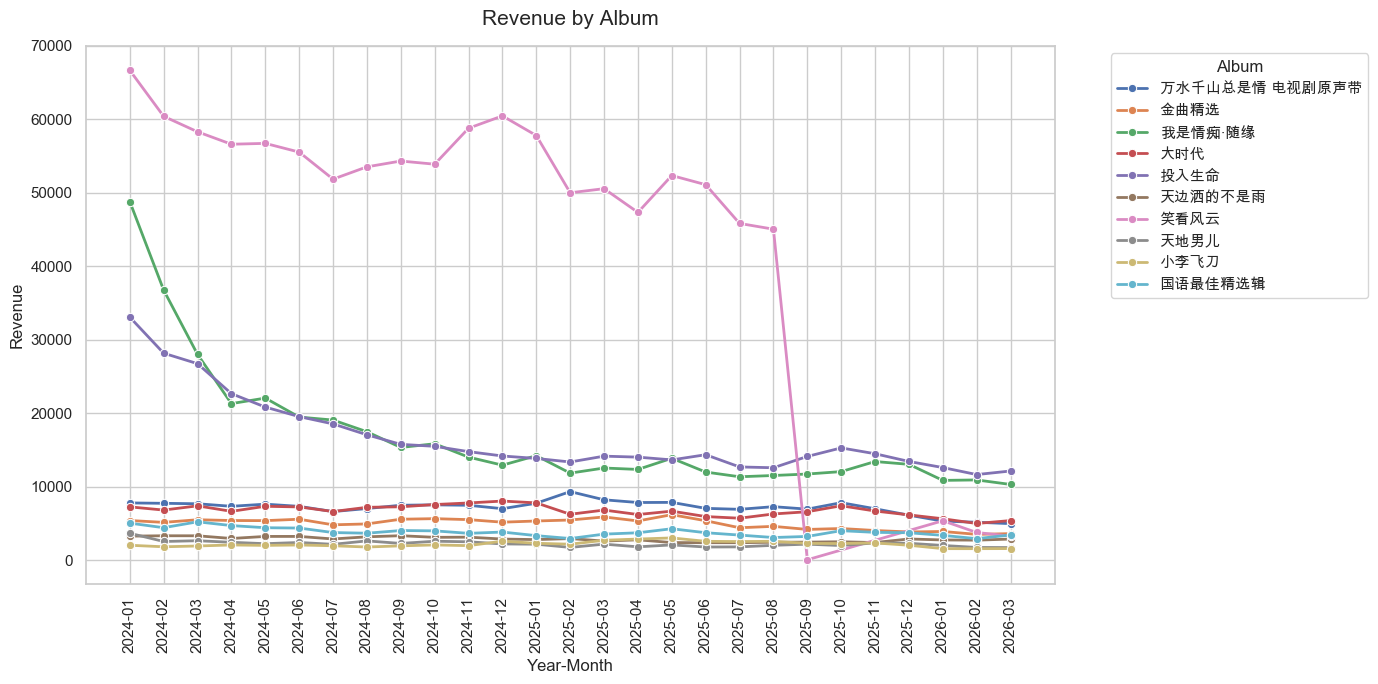

In [11]:
# Generate Excel report for Albums
album_final = generate_album_report(df_filtered, OUTPUT_ALBUM_REPORT_PATH)
display(album_final.head())

# Find top albums contribute to total revenue
revenue_by_album = (
    df_filtered
    .groupby(['UPC'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
revenue_by_album = revenue_by_album.sort_values('revenue', ascending=False)
print(f"Top {TOP_N_ALBUMS} albums contribute to {revenue_by_album['revenue'].head(TOP_N_ALBUMS).sum()/revenue_by_album['revenue'].sum():.2%} of total revenue.")

# Plot monthly trend lines for the top albums
top_n_album_list = revenue_by_album['UPC'].head(TOP_N_ALBUMS).tolist()
revenue_by_album_per_month = (
    df_filtered
    .groupby(['UPC', 'YearMonth'])
    .agg(
        album=('Album', 'first'),
        revenue=('Revenue', 'sum')
    )
    .reset_index()
)
top_album_trend = revenue_by_album_per_month[
    revenue_by_album_per_month['UPC'].isin(top_n_album_list)
]
plotting.plot_revenue_by_album(top_album_trend)